In [81]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [82]:
from sklearn.preprocessing import MinMaxScaler

In [83]:
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

pd.set_option("display.max_columns",None)

In [84]:
data = pd.read_csv("data_set.csv")
data.head()

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


In [85]:
df = data.copy()
df.head()

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


In [86]:
df.tail

<bound method NDFrame.tail of              Date        Time State     Group  Unit  Sales
0      1-Oct-2020     Morning    WA      Kids     8  20000
1      1-Oct-2020     Morning    WA       Men     8  20000
2      1-Oct-2020     Morning    WA     Women     4  10000
3      1-Oct-2020     Morning    WA   Seniors    15  37500
4      1-Oct-2020   Afternoon    WA      Kids     3   7500
...           ...         ...   ...       ...   ...    ...
7555  30-Dec-2020   Afternoon   TAS   Seniors    14  35000
7556  30-Dec-2020     Evening   TAS      Kids    15  37500
7557  30-Dec-2020     Evening   TAS       Men    15  37500
7558  30-Dec-2020     Evening   TAS     Women    11  27500
7559  30-Dec-2020     Evening   TAS   Seniors    13  32500

[7560 rows x 6 columns]>

In [87]:
df.shape

(7560, 6)

In [88]:
df.columns

Index(['Date', 'Time', 'State', 'Group', 'Unit', 'Sales'], dtype='object')

In [89]:
df.dtypes

Date     object
Time     object
State    object
Group    object
Unit      int64
Sales     int64
dtype: object

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


In [91]:
df.describe()

,Unit,Sales
count,7560.000000,7560.000000
mean,18.005423,45013.558201
std,12.901403,32253.506944
min,2.000000,5000.000000
25%,8.000000,20000.000000
50%,14.000000,35000.000000
75%,26.000000,65000.000000
max,65.000000,162500.000000


In [92]:
df.describe(include="all")

,Date,Time,State,Group,Unit,Sales
count,7560,7560,7560,7560,7560.000000,7560.000000
unique,90,3,7,4,NaN,NaN
top,1-Oct-2020,Morning,WA,Kids,NaN,NaN
freq,84,2520,1080,1890,NaN,NaN
mean,NaN,NaN,NaN,NaN,18.005423,45013.558201
std,NaN,NaN,NaN,NaN,12.901403,32253.506944
min,NaN,NaN,NaN,NaN,2.000000,5000.000000
25%,NaN,NaN,NaN,NaN,8.000000,20000.000000
50%,NaN,NaN,NaN,NaN,14.000000,35000.000000
75%,NaN,NaN,NaN,NaN,26.000000,65000.000000


In [93]:
df.isnull().sum()

Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

In [94]:
df.duplicated().sum()

np.int64(0)

In [95]:
df.drop_duplicates(inplace=True)

df.reset_index(drop=True,inplace=True)

In [96]:
df["Date"] = pd.to_datetime(df["Date"])
df.dtypes

Date     datetime64[ns]
Time             object
State            object
Group            object
Unit              int64
Sales             int64
dtype: object

In [97]:
scaler = MinMaxScaler()

df[["Sales", "Unit"]] = scaler.fit_transform(df[['Sales', 'Unit']])

df.head()

,Date,Time,State,Group,Unit,Sales
0,2020-10-01,Morning,WA,Kids,0.095238,0.095238
1,2020-10-01,Morning,WA,Men,0.095238,0.095238
2,2020-10-01,Morning,WA,Women,0.031746,0.031746
3,2020-10-01,Morning,WA,Seniors,0.206349,0.206349
4,2020-10-01,Afternoon,WA,Kids,0.015873,0.015873


In [98]:
df["Year"] = df["Date"].dt.year

df["Month"] = df["Date"].dt.month

df["Month_Name"] = df["Date"].dt.month_name()

df["Week"] = df["Date"].dt.isocalendar().week

df["Quarter"] = df["Date"].dt.quarter

df["Day"] = df["Date"].dt.day

df["Day_Name"] = df["Date"].dt.day_name()

df["Hour"] = df["Date"].dt.hour

In [99]:
df.head()

,Date,Time,State,Group,Unit,Sales,Year,Month,Month_Name,Week,Quarter,Day,Day_Name,Hour
0,2020-10-01,Morning,WA,Kids,0.095238,0.095238,2020,10,October,40,4,1,Thursday,0
1,2020-10-01,Morning,WA,Men,0.095238,0.095238,2020,10,October,40,4,1,Thursday,0
2,2020-10-01,Morning,WA,Women,0.031746,0.031746,2020,10,October,40,4,1,Thursday,0
3,2020-10-01,Morning,WA,Seniors,0.206349,0.206349,2020,10,October,40,4,1,Thursday,0
4,2020-10-01,Afternoon,WA,Kids,0.015873,0.015873,2020,10,October,40,4,1,Thursday,0


In [100]:
df.groupby("State")["Sales"].sum()

State
NSW    441.714286
NT     109.079365
QLD    177.888889
SA     339.412698
TAS    110.222222
VIC    635.968254
WA     106.365079
Name: Sales, dtype: float64

In [101]:
df.groupby("Group")["Sales"].mean()

Group
Kids       0.254044
Men        0.256320
Seniors    0.250567
Women      0.255287
Name: Sales, dtype: float64

In [102]:
df["Sales"].describe()
df["Unit"].describe()

mean_sales = df["Sales"].mean()
median_sales = df["Sales"].median()
std_sales = df["Sales"].std()
mode_sales = df["Sales"].mode()

print("Sales Describe")
print("Sales Mean : ", mean_sales)
print(f"Sales Median : {median_sales}")
print(f"Sales Std : {std_sales}")
print(f"Sales Mode : {mode_sales}")

mean_unit = df["Unit"].mean()
median_unit = df["Unit"].median()
std_unit = df["Unit"].std()
mode_unit = df["Unit"].mode()

print("\nUnit Describe")
print(f"Unit Mean : {mean_unit}")
print(f"Unit Median : {median_unit}")
print(f"Unit Std : {std_unit}")
print(f"Unit Mode : {mode_unit}")

Sales Describe
Sales Mean :  0.25405433778449654
Sales Median : 0.1904761904761905
Sales Std : 0.2047841710728009
Sales Mode : 0    0.111111
Name: Sales, dtype: float64

Unit Describe
Unit Mean : 0.2540543377844965
Unit Median : 0.19047619047619047
Unit Std : 0.20478417107280086
Unit Mode : 0    0.111111
Name: Unit, dtype: float64


In [103]:
print("Sales Describe")
print(df["Sales"].describe())

print()

print("Mean :",df["Sales"].mean())

print("Median :",df["Sales"].median())

print("Mode :")

print(df["Sales"].mode())

print("Std :",df["Sales"].std())

print("Variance :",df["Sales"].var())

print("Skew :",df["Sales"].skew())

print("Kurtosis :",df["Sales"].kurt())

Sales Describe
count    7560.000000
mean        0.254054
std         0.204784
min         0.000000
25%         0.095238
50%         0.190476
75%         0.380952
max         1.000000
Name: Sales, dtype: float64

Mean : 0.25405433778449654
Median : 0.1904761904761905
Mode :
0    0.111111
Name: Sales, dtype: float64
Std : 0.2047841710728009
Variance : 0.04193655672197418
Skew : 1.0855501535060812
Kurtosis : 0.6614172266616087


In [104]:
print("Unit Describe")
print(df["Unit"].describe())

print()

print("Mean :",df["Unit"].mean())

print("Median :",df["Unit"].median())

print(df["Unit"].mode())

print("Std :",df["Unit"].std())

print("Variance :",df["Unit"].var())

Unit Describe
count    7560.000000
mean        0.254054
std         0.204784
min         0.000000
25%         0.095238
50%         0.190476
75%         0.380952
max         1.000000
Name: Unit, dtype: float64

Mean : 0.2540543377844965
Median : 0.19047619047619047
0    0.111111
Name: Unit, dtype: float64
Std : 0.20478417107280086
Variance : 0.04193655672197417


In [105]:
group_sales = (
    df.groupby("Group")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(group_sales)
print(f"Group for Highest Sales : {group_sales.idxmax()}")
print(f"Group for Lowest Sales : {group_sales.idxmin()}")

Group
Men        484.444444
Women      482.492063
Kids       480.142857
Seniors    473.571429
Name: Sales, dtype: float64
Group for Highest Sales :  Men
Group for Lowest Sales :  Seniors


In [106]:
state_sales = (
    df.groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(state_sales)
print(f"State for Highest Sales : {state_sales.idxmax()}")
print(f"State for Lowest Sales : {state_sales.idxmin()}")

State
VIC    635.968254
NSW    441.714286
SA     339.412698
QLD    177.888889
TAS    110.222222
NT     109.079365
WA     106.365079
Name: Sales, dtype: float64
State for Highest Sales :  VIC
State for Lowest Sales :  WA


In [107]:
weekly = (
    df.groupby("Week")["Sales"]
    .sum()
)

weekly

Week
40     84.857143
41    152.777778
42    150.476190
43    151.587302
44    122.460317
45    113.809524
46    115.761905
47    115.380952
48    117.698413
49    169.412698
50    181.492063
51    182.317460
52    183.047619
53     79.571429
Name: Sales, dtype: float64

In [108]:
monthly = (
    df.groupby("Month_Name")["Sales"]
    .sum()
)

monthly

Month_Name
December    779.238095
November    495.761905
October     645.650794
Name: Sales, dtype: float64

In [109]:
quarterly = (
    df.groupby("Quarter")["Sales"]
    .sum()
)

quarterly

Quarter
4    1920.650794
Name: Sales, dtype: float64

In [110]:
hourely = df.groupby("Hour")["Sales"].sum()
hourely

Hour
0    1920.650794
Name: Sales, dtype: float64

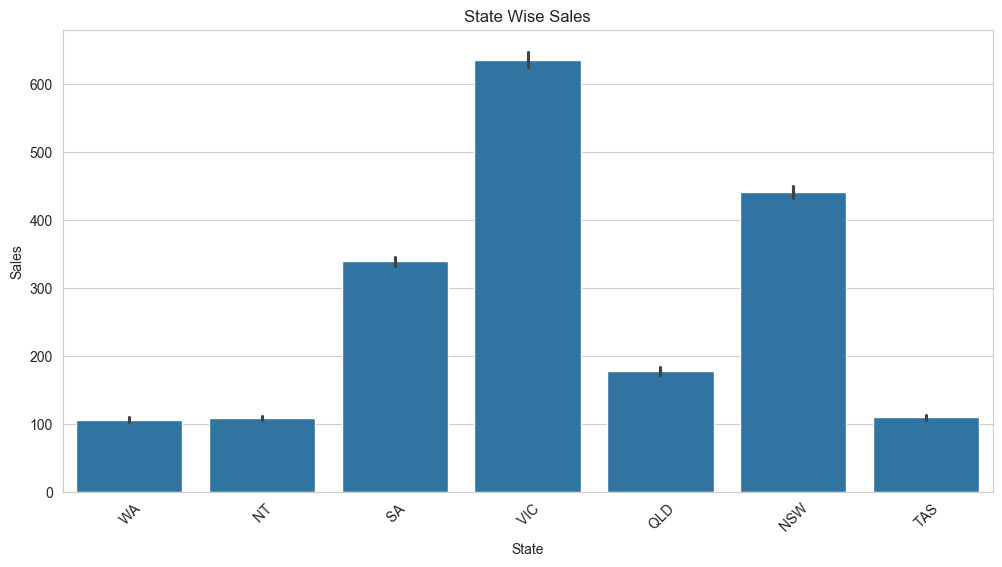

In [111]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x="State",
    y="Sales",
    estimator=sum
)

plt.xticks(rotation=45)

plt.title("State Wise Sales")

plt.show()

<Figure size 1200x600 with 0 Axes>

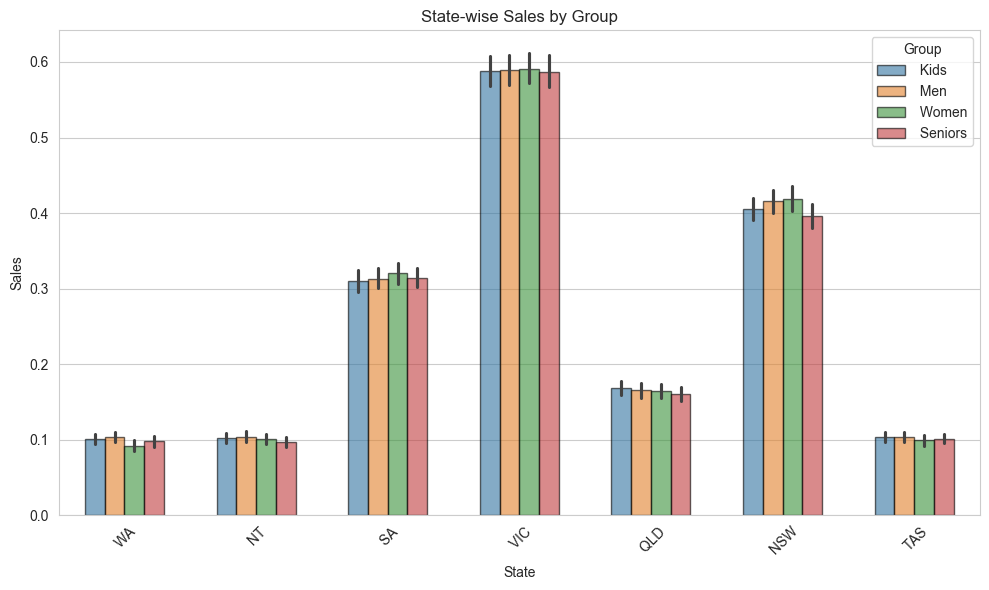

In [112]:
plt.figure(figsize=(12,6))

plt.figure(figsize=(10,6))
sns.barplot(data=df, x='State', y='Sales', hue='Group', width=0.6, alpha=0.6, edgecolor="black")
plt.title("State-wise Sales by Group")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

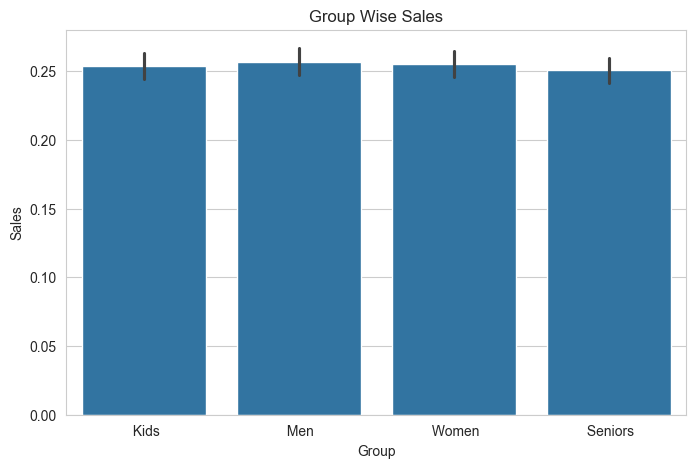

In [113]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Group",
    y="Sales"
)

plt.title("Group Wise Sales")

plt.show()

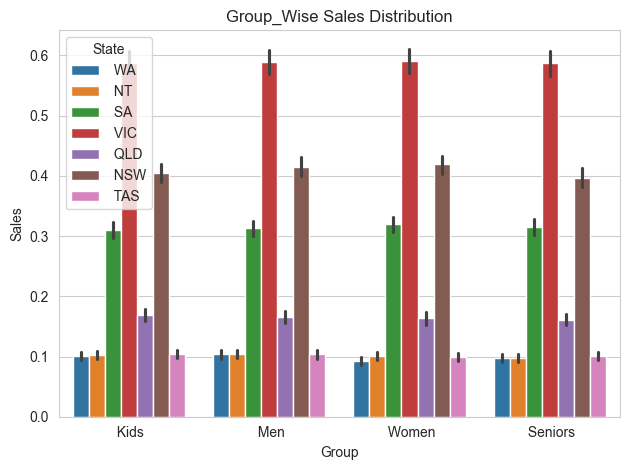

In [114]:
sns.barplot(data=df, x="Group", y="Sales", hue="State")
plt.title("Group_Wise Sales Distribution")
plt.tight_layout()

<Axes: xlabel='Time', ylabel='Sales'>

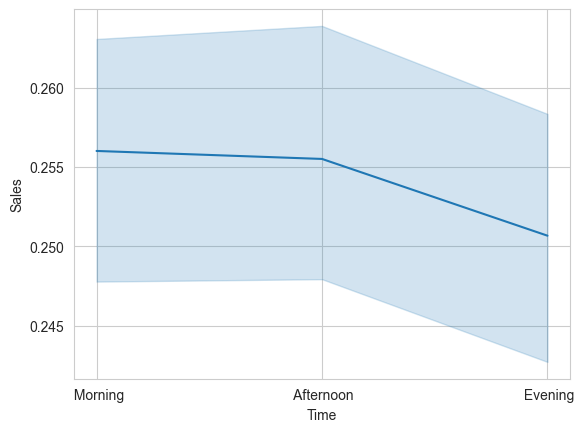

In [115]:
sns.lineplot(data=df, x="Time", y="Sales")

In [118]:
df["Hour"].value_counts()

Hour
0    7560
Name: count, dtype: int64

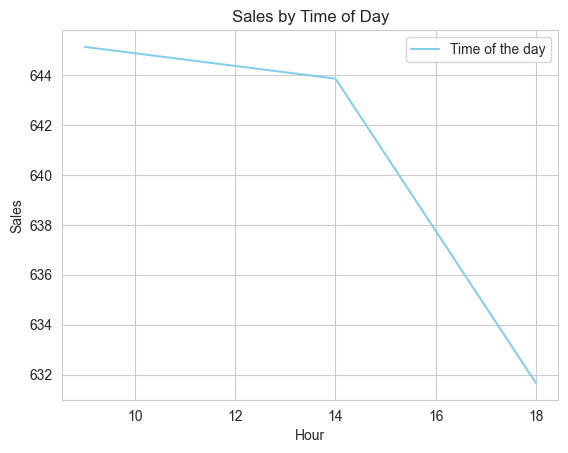

In [119]:
time_map = {
    " Morning" : 9, 
    " Afternoon" : 14, 
    " Evening" : 18, 
    " Night" : 21
}


df["Hour"] = df["Time"].map(time_map)

time_sales = df.groupby("Hour")["Sales"].sum()
sns.lineplot(x=time_sales.index, y=time_sales.values, 
            label="Time of the day", color="skyblue")
plt.title("Sales by Time of Day")
plt.xlabel("Hour")
plt.ylabel("Sales")
plt.legend()
plt.show()

In [120]:
df["Hour"].value_counts()

Hour
9     2520
14    2520
18    2520
Name: count, dtype: int64

<Axes: title={'center': 'Monthly Sales'}, xlabel='Month_Name'>

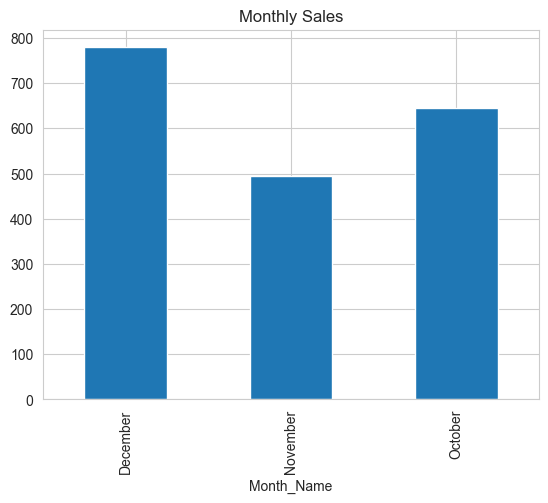

In [122]:
monthly.plot(kind="bar", title="Monthly Sales")

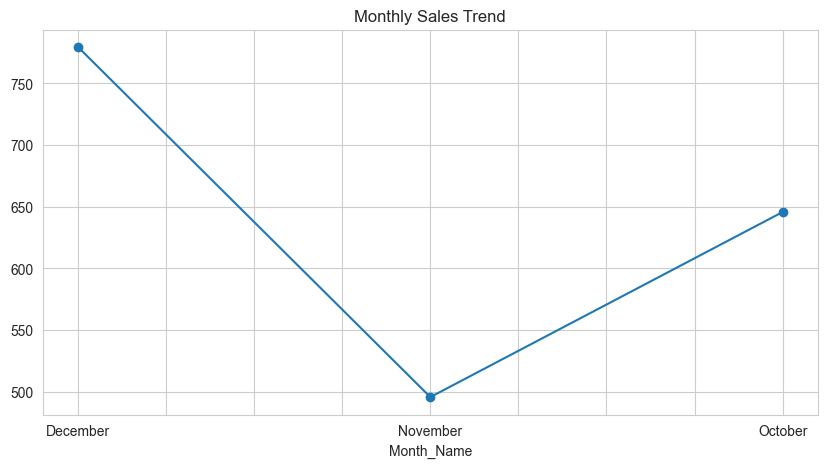

In [123]:
plt.figure(figsize=(10,5))

monthly.plot(marker="o")

plt.title("Monthly Sales Trend")

plt.grid(True)

plt.show()

<Axes: title={'center': 'Weekly Sales Trend'}, xlabel='Week'>

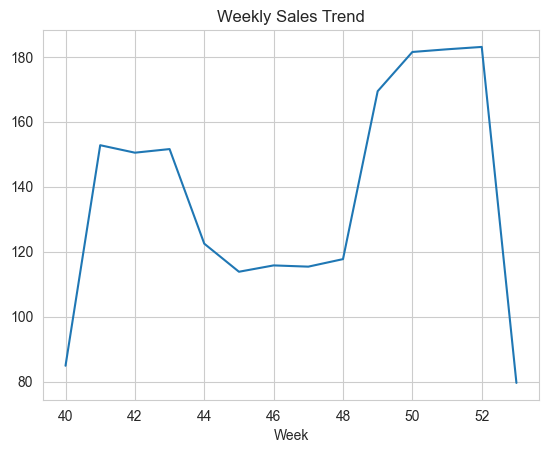

In [124]:
weekly.plot(kind="line", title="Weekly Sales Trend")

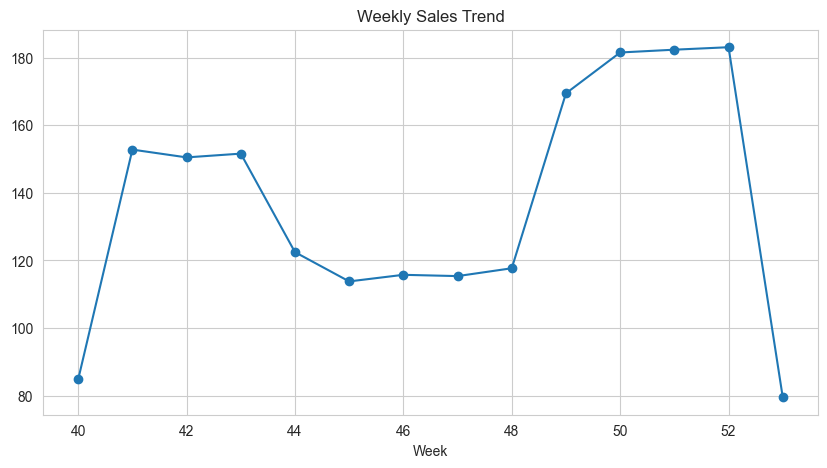

In [125]:
plt.figure(figsize=(10,5))

weekly.plot(marker="o")

plt.title("Weekly Sales Trend")

plt.grid(True)

plt.show()

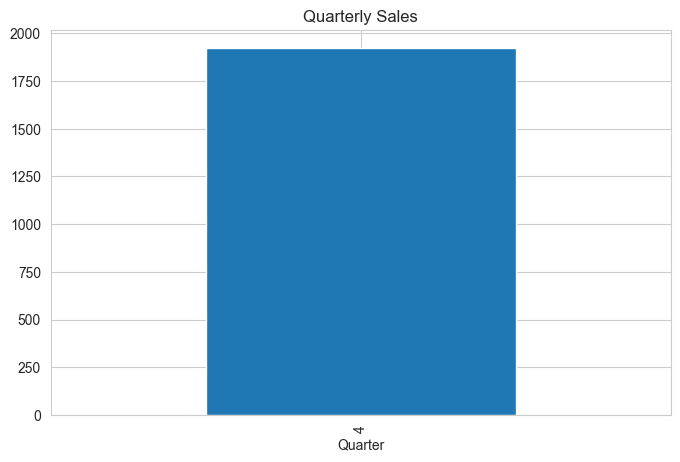

In [126]:
plt.figure(figsize=(8,5))

quarterly.plot(kind="bar")

plt.title("Quarterly Sales")

plt.show()

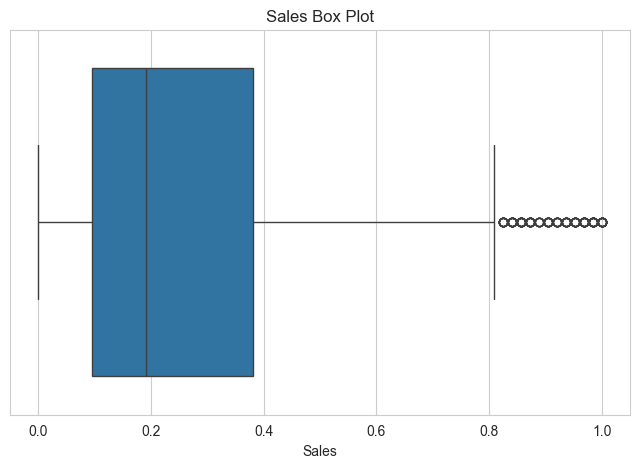

In [127]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Sales"]
)

plt.title("Sales Box Plot")

plt.show()

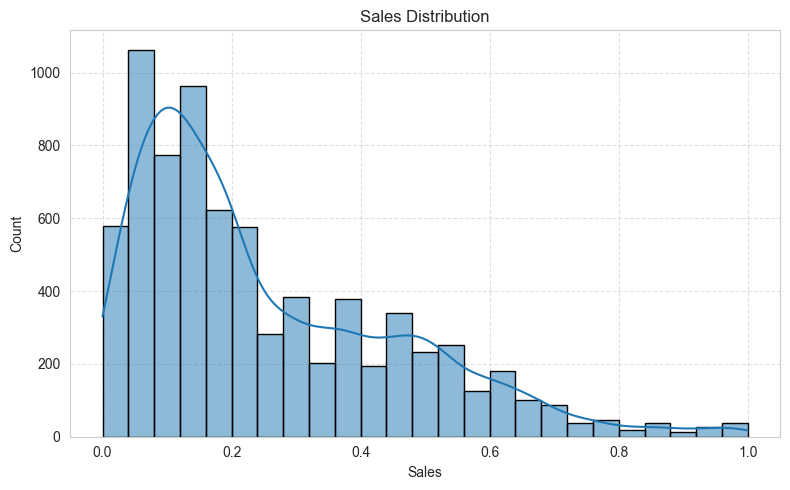

In [128]:
plt.figure(figsize=(8,5))
sns.histplot(data = df, x="Sales", kde=True, palette="rainbow", edgecolor="black", bins=25)
plt.title("Sales Distribution")
plt.tight_layout()
plt.grid(linestyle="--", alpha=0.6)

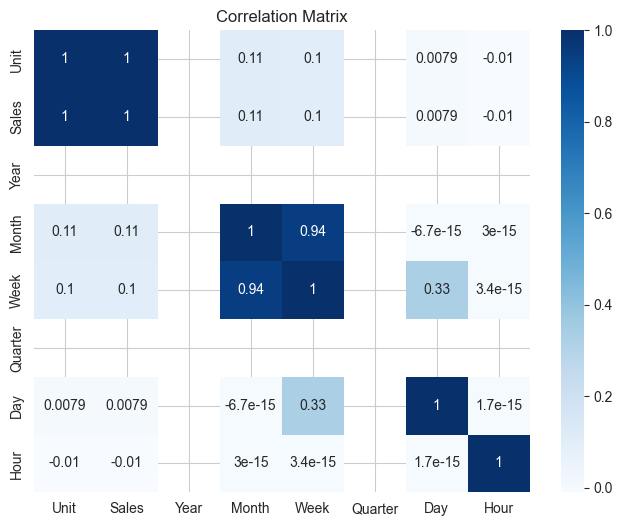

In [129]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Matrix")

plt.show()

In [130]:
corr = df.corr(numeric_only=True)
print(corr)

             Unit     Sales  Year         Month          Week  Quarter  \
Unit     1.000000  1.000000   NaN  1.056869e-01  1.003931e-01      NaN   
Sales    1.000000  1.000000   NaN  1.056869e-01  1.003931e-01      NaN   
Year          NaN       NaN   NaN           NaN           NaN      NaN   
Month    0.105687  0.105687   NaN  1.000000e+00  9.416220e-01      NaN   
Week     0.100393  0.100393   NaN  9.416220e-01  1.000000e+00      NaN   
Quarter       NaN       NaN   NaN           NaN           NaN      NaN   
Day      0.007928  0.007928   NaN -6.685896e-15  3.280133e-01      NaN   
Hour    -0.010308 -0.010308   NaN  3.006382e-15  3.382610e-15      NaN   

                  Day          Hour  
Unit     7.928101e-03 -1.030788e-02  
Sales    7.928101e-03 -1.030788e-02  
Year              NaN           NaN  
Month   -6.685896e-15  3.006382e-15  
Week     3.280133e-01  3.382610e-15  
Quarter           NaN           NaN  
Day      1.000000e+00  1.671935e-15  
Hour     1.671935e-15  1.0000

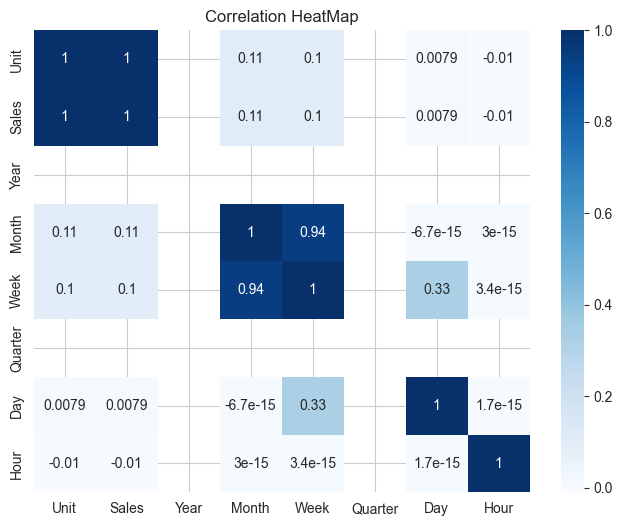

In [131]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues"
)

plt.title("Correlation HeatMap")

plt.show()

In [132]:
sales_rank = (
    df.groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(sales_rank)

State
VIC    635.968254
NSW    441.714286
SA     339.412698
QLD    177.888889
TAS    110.222222
NT     109.079365
WA     106.365079
Name: Sales, dtype: float64


In [133]:
print(sales_rank.head())

State
VIC    635.968254
NSW    441.714286
SA     339.412698
QLD    177.888889
TAS    110.222222
Name: Sales, dtype: float64


In [134]:
print(sales_rank.tail())

State
SA     339.412698
QLD    177.888889
TAS    110.222222
NT     109.079365
WA     106.365079
Name: Sales, dtype: float64


In [135]:
df.head()

,Date,Time,State,Group,Unit,Sales,Year,Month,Month_Name,Week,Quarter,Day,Day_Name,Hour
0,2020-10-01,Morning,WA,Kids,0.095238,0.095238,2020,10,October,40,4,1,Thursday,9
1,2020-10-01,Morning,WA,Men,0.095238,0.095238,2020,10,October,40,4,1,Thursday,9
2,2020-10-01,Morning,WA,Women,0.031746,0.031746,2020,10,October,40,4,1,Thursday,9
3,2020-10-01,Morning,WA,Seniors,0.206349,0.206349,2020,10,October,40,4,1,Thursday,9
4,2020-10-01,Afternoon,WA,Kids,0.015873,0.015873,2020,10,October,40,4,1,Thursday,14
